# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import naive_bayes
from sklearn import metrics
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

In [2]:
sms_data = pd.read_csv('data/spam_or_not_spam.csv')
sms_data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [3]:
sms_data['label'] = sms_data['label'].astype('int8')
sms_data['email'] = sms_data['email'].astype('object')

In [4]:
sms_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   2999 non-null   object
 1   label   3000 non-null   int8  
dtypes: int8(1), object(1)
memory usage: 26.5+ KB


In [5]:
# смотрим распределение классов
sms_data['label'].value_counts()

label
0    2500
1     500
Name: count, dtype: int64

In [6]:
label_counts = round(sms_data['label'].value_counts(normalize=True) * 100, 2)
label_counts

label
0    83.33
1    16.67
Name: proportion, dtype: float64

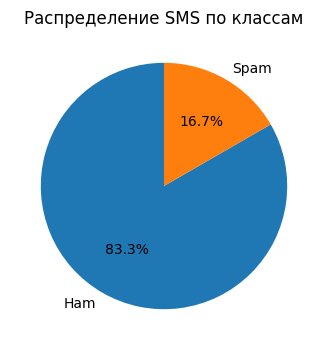

In [7]:
# Создаем круговую диаграмму
pie_labels = ['Ham', 'Spam']  # подписи только на диаграмме

plt.figure(figsize=(4, 4))
plt.pie(label_counts, 
        labels=pie_labels,  # новые подписи на диаграмме
        autopct='%1.1f%%', 
        startangle=90)
plt.title('Распределение SMS по классам')
plt.show()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [9]:
data_clean = sms_data.copy()

# Заменяем пустые строки и строки из пробелов на NaN во всех столбцах
data_clean = data_clean.replace(r'^\s*$', np.nan, regex=True)

# Удаляем строки с любыми пропущенными значениями
data_clean = data_clean.dropna()

# Проверяем результат
print(f"Размер после очистки: {data_clean.shape}")
print(f"Осталось пропусков:\n{data_clean.isnull().sum()}")

Размер после очистки: (2997, 2)
Осталось пропусков:
email    0
label    0
dtype: int64


In [10]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 2997 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   2997 non-null   object
 1   label   2997 non-null   int8  
dtypes: int8(1), object(1)
memory usage: 49.8+ KB


In [11]:
# переносим результат
sms_data = data_clean

Переводим данные в векторный вид:

In [12]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(sms_data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [13]:
print(f'После обработки создано {X.shape[1]} признаков')

После обработки создано 34116 признаков


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [14]:
# задаём целевой переменную
y = sms_data['label']

# выводим результат
print(f'Размер обучающей выборки: {X.shape}')
print(f'Размер тестовой выборки: {y.shape}')

Размер обучающей выборки: (2997, 34116)
Размер тестовой выборки: (2997,)


Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    stratify=y, 
    random_state=42
)

# выводим результат
print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер обучающей выборки: (2247, 34116)
Размер тестовой выборки: (750, 34116)


Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [16]:
print(f'Среднее значение целевой переменнной на тестовой выборке: {round(y_test.mean(), 3)}')

Среднее значение целевой переменнной на тестовой выборке: 0.165


## Задание 4 (3 балла)

*В библиотеке sklearn есть несколько байесовских классификаторов:*

- GaussianNB — самый простой вариант, работает с непрерывными признаками;
- MultinomialNB  — работает с категориальными признаками, текстами и несбалансированными выборками;
- ComplementNB — улучшенная версия MultinomialNB, стабильно показывает более высокое качество в задачах классификации текстов;
- BernoulliNB — версия для работы с бинарными признаками;
- CategoricalNB — работает с категориальными признаками, предполагает кодировку данных через OrdinalEncoder.

В нащем случае наиболее подходящий классификатор - ComplementNB

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [17]:
# задаём объект класса ComplementNB
CNB = naive_bayes.ComplementNB(alpha=0.01)

# обучаем модель
CNB.fit(X_train, y_train)

# предсказываем значения на тестовой выборке
y_pred_cnb = CNB.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [18]:
print(metrics.classification_report(y_test, y_pred_cnb, digits=4))

              precision    recall  f1-score   support

           0     0.9858    1.0000    0.9929       626
           1     1.0000    0.9274    0.9623       124

    accuracy                         0.9880       750
   macro avg     0.9929    0.9637    0.9776       750
weighted avg     0.9882    0.9880    0.9878       750



Нарисуйте ROC-кривую:

In [19]:
# берём вероятность класса 1
y_pred_proba_cnb = CNB.predict_proba(X_test)[:, 1]

# ROC-кривая
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba_cnb)
auc = metrics.roc_auc_score(y_test, y_pred_proba_cnb)

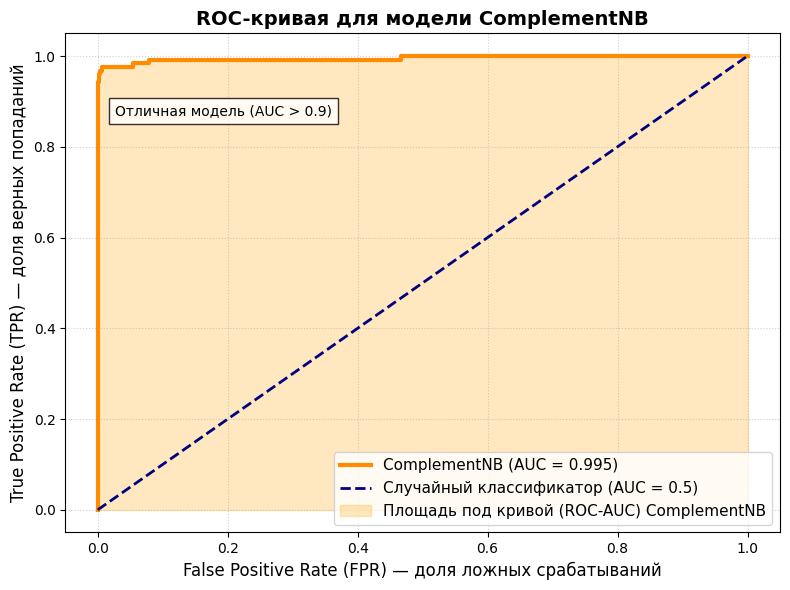


 AUC = 0.995 


In [20]:
# Создаём полотно
plt.figure(figsize=(8, 6), dpi=100)

# Основная ROC-кривая
plt.plot(fpr, tpr, 
         color='darkorange', 
         lw=3, 
         label=f'ComplementNB (AUC = {auc:.3f})')

# Диагональная линия (случайное угадывание)
plt.plot([0, 1], [0, 1], 
         color='navy', 
         lw=2, 
         linestyle='--', 
         label='Случайный классификатор (AUC = 0.5)')

# Заливка области под кривой (наглядно показывает AUC)
plt.fill_between(fpr, tpr, 
                 step='pre', 
                 alpha=0.25, 
                 color='orange', 
                 label=f'Площадь под кривой (ROC-AUC) {CNB.__class__.__name__}')

# Настройки осей и сетки
plt.xlabel('False Positive Rate (FPR) — доля ложных срабатываний', fontsize=12)
plt.ylabel('True Positive Rate (TPR) — доля верных попаданий', fontsize=12)
plt.title('ROC-кривая для модели ComplementNB', fontsize=14, fontweight='bold')

# Сетка для удобства чтения
plt.grid(True, linestyle=':', alpha=0.6)

# Легенда в лучшем месте
plt.legend(loc="lower right", fontsize=11)

# Добавляем подпись с интерпретацией
if auc >= 0.9:
    text = "Отличная модель (AUC > 0.9)"
elif auc >= 0.8:
    text = "Хорошая модель (AUC > 0.8)"
elif auc >= 0.7:
    text = "Приемлемая модель (AUC > 0.7)"
else:
    text = "Модель слабая (AUC < 0.7)"

plt.figtext(0.15, 0.8, f"{text}", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Дополнительно: выводим AUC крупно
print("\n" + "="*40)
print(f" AUC = {auc:.3f} ")
print("="*40)

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

ПЕРЕБОР ALPHA С КРОСС-ВАЛИДАЦИЕЙ (CV=5)


C:\Users\HP\AppData\Local\Temp\ipykernel_9512\1154635540.py:70: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([min(alpha_values) * 0.8, max(alpha_values) * 1.2])


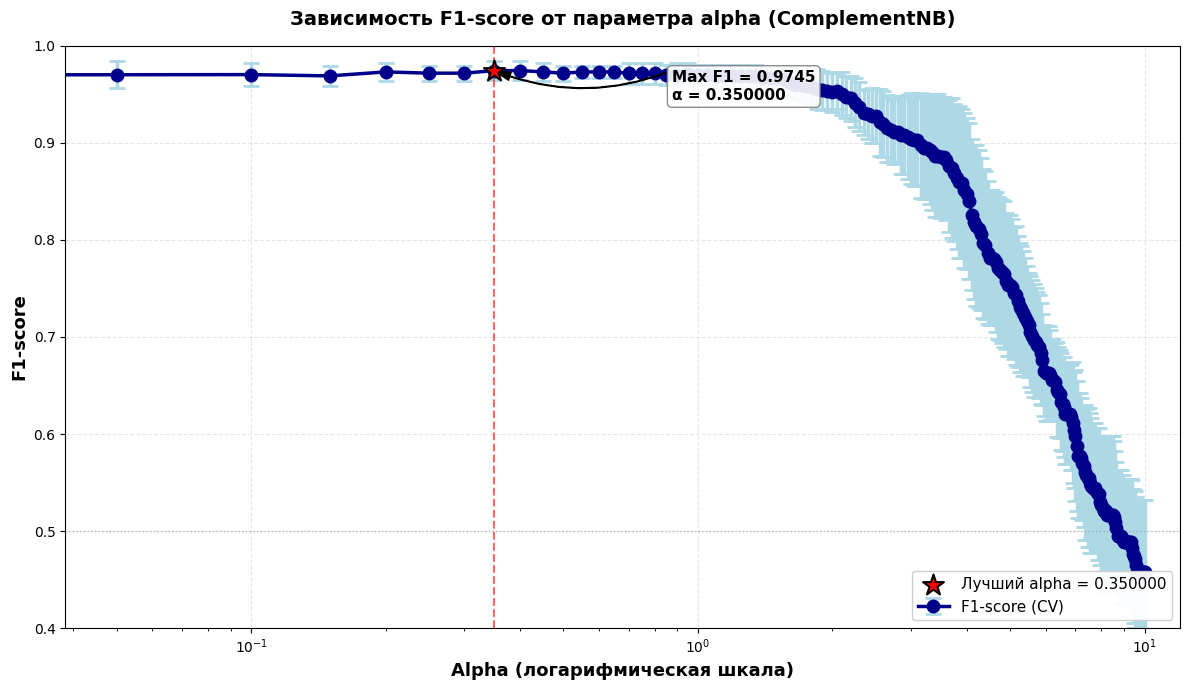


ИТОГОВЫЙ АНАЛИЗ

✅ Оптимальный alpha: 0.350000
✅ Соответствующий F1: 0.9745 ± 0.0098

📊 СТАТИСТИКА:
   • Максимальный F1: 0.9745
   • Минимальный F1:  0.4433
   • Разброс F1:      0.5312 (54.51%)

📊 ВЫВОД: Параметр alpha СУЩЕСТВЕННО ВЛИЯЕТ на качество классификации
   (различия в F1 составляют 53.12%)

💡 Рекомендация: ОБЯЗАТЕЛЬНО используйте подобранное alpha = 0.350000

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ

📊 Метрики на тестовой выборке:
   • F1-score:  0.9837
   • ROC-AUC:   0.9984
   • Accuracy:  0.9947

📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       626
           1       0.99      0.98      0.98       124

    accuracy                           0.99       750
   macro avg       0.99      0.99      0.99       750
weighted avg       0.99      0.99      0.99       750


ИТОГОВЫЙ ВЫВОД

🎯 ЗАВИСИМОСТЬ ОТ ALPHA:
   • Разброс F1: 0.5312 (54.51%)
   • 🔴 СУЩЕСТВЕННО ВЛИЯЕТ

📌 РЕКОМЕНДУЕМОЕ ЗНАЧЕНИЕ:
   • alpha = 0.350

In [35]:
# ========= 1. ПЕРЕБОР ЗНАЧЕНИЙ ALPHA =========
alpha_values = np.round(np.linspace(0, 10, num=201), 5)
all_scores = []

print("="*60)
print("ПЕРЕБОР ALPHA С КРОСС-ВАЛИДАЦИЕЙ (CV=5)")
print("="*60)

for alpha in alpha_values:
    cnb = naive_bayes.ComplementNB(alpha=alpha)
    scores = cross_val_score(cnb, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    all_scores.append(scores)

# ========= 2. РАСЧЁТ СТАТИСТИК =========
means = [np.mean(scores) for scores in all_scores]
stds = [np.std(scores) for scores in all_scores]

# Находим лучший alpha
best_idx = np.argmax(means)
best_alpha = alpha_values[best_idx]
best_f1 = means[best_idx]
best_std = stds[best_idx]

# ========= 3. ПОСТРОЕНИЕ ГРАФИКА =========
fig, ax = plt.subplots(figsize=(12, 7))

# Основной график: F1-score с ошибками
ax.errorbar(alpha_values, means, yerr=stds, 
            fmt='o-', capsize=6, capthick=2,
            color='darkblue', ecolor='lightblue',
            markersize=9, linewidth=2.5,
            label='F1-score (CV)')

# Выделяем лучшую точку
ax.scatter(best_alpha, best_f1, 
           color='red', s=250, marker='*', 
           edgecolor='black', linewidth=1.5, zorder=5,
           label=f'Лучший alpha = {best_alpha:.6f}')

# Вертикальная линия на лучшем значении
ax.axvline(x=best_alpha, color='red', 
           linestyle='--', linewidth=1.5, alpha=0.6)

# Аннотация с лучшим значением
ax.annotate(f'Max F1 = {best_f1:.4f}\nα = {best_alpha:.6f}',
            xy=(best_alpha, best_f1),
            xytext=(best_alpha * 2.5, best_f1 - 0.03),
            arrowprops=dict(facecolor='black', 
                          width=0.5, 
                          headwidth=6,
                          connectionstyle="arc3, rad=-0.2"),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Настройка осей
ax.set_xscale('log')
ax.set_xlabel('Alpha (логарифмическая шкала)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-score', fontsize=13, fontweight='bold')
ax.set_title('Зависимость F1-score от параметра alpha (ComplementNB)', 
             fontsize=14, fontweight='bold', pad=15)

# Сетка
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Легенда
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

# Границы осей
ax.set_ylim([max(0.4, min(means) - 0.05), min(1.0, max(means) + 0.05)])
ax.set_xlim([min(alpha_values) * 0.8, max(alpha_values) * 1.2])

# Горизонтальная линия на уровне 0.5 (случайная модель)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1, label='Случайный уровень (0.5)')

plt.tight_layout()
plt.show()

# ========= 4. ВЫВОДЫ =========
print("\n" + "="*60)
print("ИТОГОВЫЙ АНАЛИЗ")
print("="*60)

print(f"\n✅ Оптимальный alpha: {best_alpha:.6f}")
print(f"✅ Соответствующий F1: {best_f1:.4f} ± {best_std:.4f}")

# Проверка значимости различий
f1_range = max(means) - min(means)

print(f"\n📊 СТАТИСТИКА:")
print(f"   • Максимальный F1: {max(means):.4f}")
print(f"   • Минимальный F1:  {min(means):.4f}")
print(f"   • Разброс F1:      {f1_range:.4f} ({f1_range/max(means)*100:.2f}%)")

if f1_range < 0.01:
    print("\n📊 ВЫВОД: Параметр alpha НЕ ВЛИЯЕТ на качество классификации")
    print("   (различия в F1 < 1% во всём диапазоне)")
    print(f"\n💡 Рекомендация: можно использовать любое alpha от {min(alpha_values):.6f} до {max(alpha_values):.2f}")
elif f1_range < 0.03:
    print("\n📊 ВЫВОД: Параметр alpha СЛАБО ВЛИЯЕТ на качество классификации")
    print("   (различия в F1 составляют 1-3%)")
    print(f"\n💡 Рекомендация: используйте alpha = {best_alpha:.6f} (лучший по F1)")
    print(f"   Избегайте экстремально больших значений (> 5.0)")
else:
    print("\n📊 ВЫВОД: Параметр alpha СУЩЕСТВЕННО ВЛИЯЕТ на качество классификации")
    print(f"   (различия в F1 составляют {f1_range:.2%})")
    print(f"\n💡 Рекомендация: ОБЯЗАТЕЛЬНО используйте подобранное alpha = {best_alpha:.6f}")

# ========= 5. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ =========
print("\n" + "="*60)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print("="*60)

best_cnb = naive_bayes.ComplementNB(alpha=best_alpha)
best_cnb.fit(X_train, y_train)
y_pred = best_cnb.predict(X_test)
y_pred_proba = best_cnb.predict_proba(X_test)[:, 1]

from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, classification_report

test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Метрики на тестовой выборке:")
print(f"   • F1-score:  {test_f1:.4f}")
print(f"   • ROC-AUC:   {test_auc:.4f}")
print(f"   • Accuracy:  {test_acc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n" + "="*60)
print("ИТОГОВЫЙ ВЫВОД")
print("="*60)
print(f"""
🎯 ЗАВИСИМОСТЬ ОТ ALPHA:
   • Разброс F1: {f1_range:.4f} ({f1_range/max(means)*100:.2f}%)
   • {"🔴 СУЩЕСТВЕННО ВЛИЯЕТ" if f1_range >= 0.03 else "🟡 СЛАБО ВЛИЯЕТ" if f1_range >= 0.01 else "🟢 НЕ ВЛИЯЕТ"}

📌 РЕКОМЕНДУЕМОЕ ЗНАЧЕНИЕ:
   • alpha = {best_alpha:.6f}
   • F1 (CV): {best_f1:.4f} ± {best_std:.4f}
   • F1 (Test): {test_f1:.4f}

💡 ИСПОЛЬЗУЙТЕ:
   model = ComplementNB(alpha={best_alpha:.6f})
""")
print("="*60)